# 05 — Preprocessing (V11)

**LEE** `dataset_v11.csv`  →  **ESCRIBE** `dataset_v11_preproc.csv`
**Anterior**: `04_nulos_outliers.ipynb`  |  **Siguiente**: `06_feature_engineering.ipynb`

## Principio: separación leaky / no-leaky
Aquí solo van transformaciones que **no miran el conjunto** (libres de leakage). Lo que
aprende parámetros (medianas por grupo, encoders, StandardScaler, selección con y) vive en
`preprocessing_pipeline.py` y se ejecuta **dentro de cada fold** de la CV (NB08).

## Cambios V11 (auditoría de decisiones)
- Se eliminan referencias obsoletas: `origen_nota_final`, `numero_eval_max`, **notas diarias 2020**.
- Se conserva `Ejercicio` (lo necesita la **validación temporal** del NB08).
- `IdNEE → tiene_NEE`; `log1p` en asistencia (ahora 66% con registro real); indicadores de presencia.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
pd.set_option('display.max_columns',80); pd.set_option('display.float_format','{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted'); plt.rcParams['figure.dpi']=110

_cwd=Path('.').resolve()
BASE_DIR=next((p for p in [_cwd,_cwd.parent,_cwd.parent.parent] if (p/'data').exists()), _cwd.parent)
sys.path.append(str(BASE_DIR)); sys.path.append(str(BASE_DIR/'notebooks'))
P_IN  = BASE_DIR/'data'/'dataset_v11.csv'
P_OUT = BASE_DIR/'data'/'dataset_v11_preproc.csv'
CAT_ORDER=['buen_alumno','en_riesgo','con_dificultades']

df_raw=pd.read_csv(P_IN)
df_raw['categoria_target']=pd.Categorical(df_raw['categoria_target'],categories=CAT_ORDER,ordered=True)
print(f'Dataset raw: {df_raw.shape}'); print(df_raw['categoria_target'].value_counts())

Dataset raw: (1205, 59)
categoria_target
buen_alumno         867
en_riesgo           213
con_dificultades    125
Name: count, dtype: int64


## 1. Eliminar columnas de leakage e identidad (operación segura)

Las variables derivadas de la evaluación FINAL (suspensos, aprobadas, nota_media_final…) **definen el target** → son leakage. `Ejercicio` se conserva para la validación temporal.

In [2]:
df=df_raw.copy()
DROP=['GuidAlumno',                       # identidad
      'total_asignaturas','suspensos','aprobadas','n_no_resueltas','nota_media_final']  # leakage del target
DROP=[c for c in DROP if c in df.columns]
df=df.drop(columns=DROP)
print(f'Eliminadas {len(DROP)}: {DROP}')
print(f'Shape: {df.shape}  |  Ejercicio conservado: {"Ejercicio" in df.columns}')

Eliminadas 6: ['GuidAlumno', 'total_asignaturas', 'suspensos', 'aprobadas', 'n_no_resueltas', 'nota_media_final']
Shape: (1205, 53)  |  Ejercicio conservado: True


## 2. Asistencia → log1p + indicadores binarios

Distribución muy sesgada (mayoría 0 faltas). `log1p` comprime la cola sin perder señal. Los indicadores capturan la presencia de faltas (binaria, distinta de la magnitud).

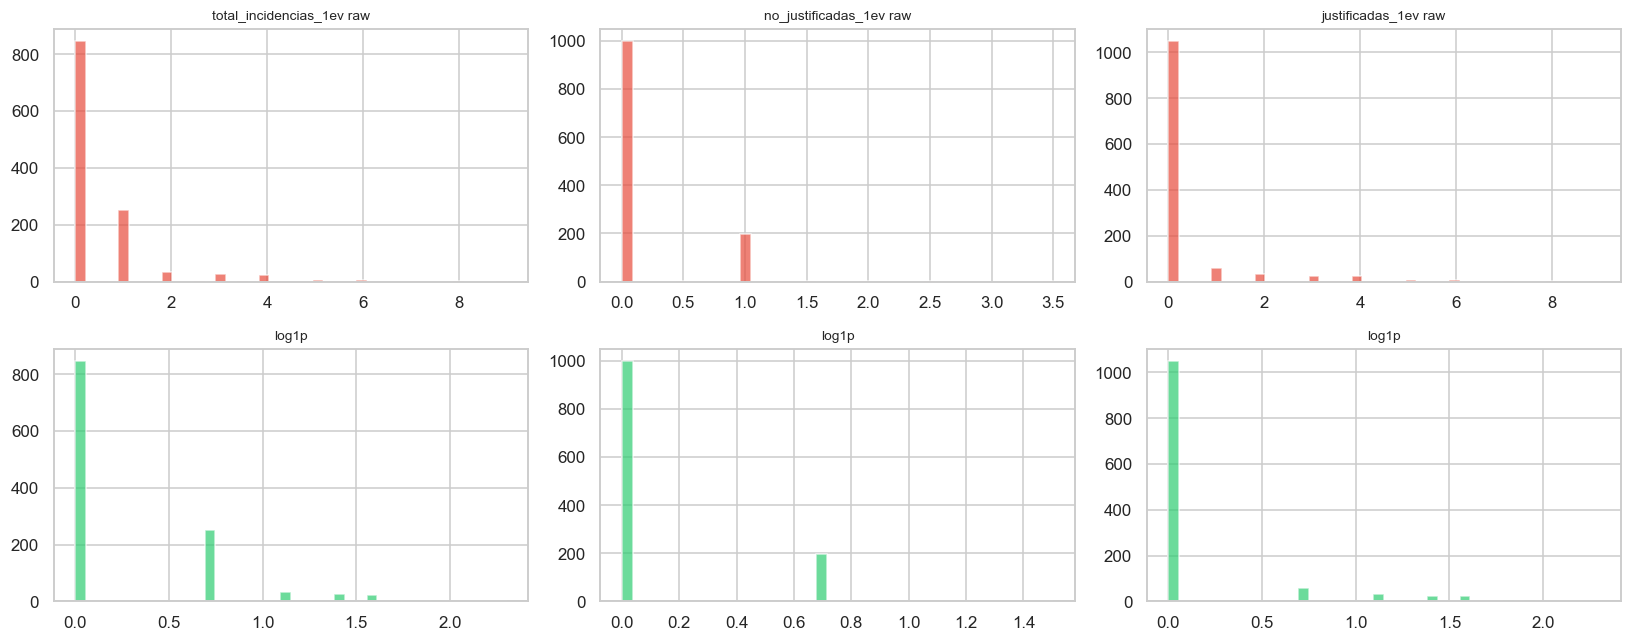

categoria_target
buen_alumno        0.095
en_riesgo          0.488
con_dificultades   0.160
Name: tiene_faltas_nojust, dtype: float64


In [3]:
ASIST=['total_incidencias_1ev','no_justificadas_1ev','justificadas_1ev']
ASIST=[c for c in ASIST if c in df.columns]
fig,ax=plt.subplots(2,len(ASIST),figsize=(5*len(ASIST),6))
for i,c in enumerate(ASIST):
    ax[0,i].hist(df[c],bins=40,color='#e74c3c',alpha=.7,edgecolor='white'); ax[0,i].set_title(f'{c} raw',fontsize=9)
    ax[1,i].hist(np.log1p(df[c]),bins=40,color='#2ecc71',alpha=.7,edgecolor='white'); ax[1,i].set_title(f'log1p',fontsize=9)
plt.tight_layout(); plt.show()
for c in ASIST: df[f'{c}_log']=np.log1p(df[c])
df['tiene_faltas_nojust']=(df['no_justificadas_1ev']>0).astype(int)
df['tiene_faltas_total'] =(df['total_incidencias_1ev']>0).astype(int)
df=df.drop(columns=ASIST)
print(df.groupby('categoria_target',observed=True)['tiene_faltas_nojust'].mean().round(3))

## 3. Indicadores de presencia (operación segura)

Marcan si el dato existía antes de imputar (el pipeline destruirá el patrón de NaN al imputar). Permiten a los árboles separar ausencia real de valor imputado.

In [4]:
BLOQUES=['LING','STEM','SOC','PERS']
for b in BLOQUES:
    c=f'nota_media__{b}'
    if c in df.columns: df[f'tiene_dato__{b}']=df[c].notna().astype(int)
if 'nota_media_1ev' in df.columns: df['sin_notas_1ev']=df['nota_media_1ev'].isna().astype(int)
# Cobertura de materias individuales (mat__): cuántas troncales cursa el alumno
mat_cols=[c for c in df.columns if c.startswith('mat__')]
if mat_cols: df['n_materias_individuales']=df[mat_cols].notna().sum(axis=1)
ind=[c for c in df.columns if c.startswith('tiene_') or c=='sin_notas_1ev']
for c in ind: print(f'  {c:<26}: {int(df[c].sum())} positivos ({df[c].mean()*100:.1f}%)')
print(f'  materias individuales: media {df["n_materias_individuales"].mean():.1f}/alumno' if mat_cols else '')

  tiene_faltas_nojust       : 206 positivos (17.1%)
  tiene_faltas_total        : 359 positivos (29.8%)
  tiene_dato__LING          : 1190 positivos (98.8%)
  tiene_dato__STEM          : 1109 positivos (92.0%)
  tiene_dato__SOC           : 1101 positivos (91.4%)
  tiene_dato__PERS          : 307 positivos (25.5%)
  sin_notas_1ev             : 0 positivos (0.0%)
  materias individuales: media 6.5/alumno


## 4. Imputaciones con constante (operación segura)

Solo valores fijos (0). `nota_std_1ev`=NaN cuando hay 1 sola asignatura → 0. Las notas base ausentes → 0 (junto al indicador). Las medianas por grupo van en el pipeline (NB08).

In [5]:
if 'nota_std_1ev' in df.columns:
    n=df['nota_std_1ev'].isna().sum(); df['nota_std_1ev']=df['nota_std_1ev'].fillna(0)
    print(f'nota_std_1ev: {n} NaN -> 0')
BASE=['nota_media_1ev','nota_min_1ev','nota_max_1ev','n_asignaturas_1ev',
      'n_aprobadas_1ev','n_suspensos_1ev','pct_aprobado_1ev']
for c in BASE:
    if c in df.columns and df[c].isna().sum():
        n=df[c].isna().sum(); df[c]=df[c].fillna(0); print(f'{c:<20}: {n} NaN -> 0')
rest=df.isna().sum(); rest=rest[rest>0]
print(f'\nNaN restantes (los imputa el pipeline por fold): {int(rest.sum())} en {len(rest)} cols')

nota_std_1ev: 39 NaN -> 0

NaN restantes (los imputa el pipeline por fold): 9760 en 30 cols


## 5. Binarizar IdNEE → tiene_NEE

`IdNEE` es un código **nominal** (76 ≠ 7.6× más NEE que 10). La señal útil es binaria: ¿tiene o no NEE?

In [6]:
if 'IdNEE' in df.columns:
    df['tiene_NEE']=(df['IdNEE'].fillna(0)>0).astype(int)
    df=df.drop(columns=['IdNEE'])
    print(f"tiene_NEE=1: {df['tiene_NEE'].sum()} ({df['tiene_NEE'].mean()*100:.1f}%)")
    print(df.groupby('categoria_target',observed=True)['tiene_NEE'].mean().round(3))

tiene_NEE=1: 8 (0.7%)
categoria_target
buen_alumno        0.007
en_riesgo          0.005
con_dificultades   0.008
Name: tiene_NEE, dtype: float64


## 6. Guardar dataset preprocesado

Contiene las operaciones seguras; los NaN que requieren mediana siguen presentes (los imputa el pipeline por fold). `NivEstudio`/`NivCurso` sin codificar (los codifica el pipeline).

In [7]:
df['target_num']=df['categoria_target'].cat.codes
df.to_csv(P_OUT,index=False)
cats=[c for c in ['NivEstudio','NivCurso'] if c in df.columns]
print(f'Categoricas que codificara el pipeline: {cats}')
otras=[c for c in df.select_dtypes(include='object').columns if c not in cats]
if otras: print(f'AVISO object inesperadas: {otras}')
print(f'\nGuardado: {P_OUT}  |  shape {df.shape}  |  NaN {int(df.isna().sum().sum())}')

Categoricas que codificara el pipeline: ['NivEstudio', 'NivCurso']

Guardado: C:\Users\emili\OneDrive\Escritorio\TFM\data\dataset_v11_preproc.csv  |  shape (1205, 61)  |  NaN 9760
